# 04 — EDA: Splunk Attack Data

The Splunk Attack Data repository contains labelled Sysmon event logs organised by:
- **293 ATT&CK technique folders** (`attack_techniques/T-code/scenario/`)
- **Malware family variants** (`malware/<family>/<variant>/`)

Every `.log` file is raw Sysmon XML — the same format as OTRF.  
The ATT&CK T-code (or malware family name) is derived from the folder structure.

**Goals:**
- Technique and malware family inventory
- Tactic distribution across the corpus
- EventID and process image distribution
- Command-line pattern analysis
- Network activity (EventIDs 3, 22)
- Technique coverage overlap with OTRF KB
- Per-technique event volume heatmap

In [1]:
import sys
sys.path.insert(0, r'h:\Challenge-3-4\cyber-anomaly-detection')

import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import yaml

from config import SPLUNK_TECHNIQUES, SPLUNK_MALWARE_DIR
from data.attack_kb.builder import build_kb

sns.set_theme(style='whitegrid')
%matplotlib inline

EID_MAP = {
    1: 'ProcessCreate', 3: 'NetworkConnect', 7: 'ImageLoad',
    10: 'ProcessAccess', 11: 'FileCreate', 12: 'RegCreate/Del',
    13: 'RegSetVal', 14: 'RegRename', 22: 'DNSEvent',
    23: 'FileDelete', 25: 'ProcessTamper',
}

## Dataset Inventory

Before loading any events, we scan the folder structure to understand what is available:

- **Technique corpus** — `attack_techniques/<T-code>/<scenario>/` — each folder holds one or more Sysmon `.log` files and a YAML descriptor that identifies which logs are Sysmon-sourced (`XmlWinEventLog:Microsoft-Windows-Sysmon/Operational`). The T-code is derived directly from the folder name, so labels are exact.
- **Malware corpus** — `malware/<family>/<variant>/` — same structure, label is the malware family name.

The YAML descriptor is used to filter out non-Sysmon logs (Security, Application, etc.) that may coexist in the same scenario directory.

ATT&CK technique folders : 293
Total scenario dirs      : 1047
Total .log files         : 1618

Malware families : 37
Total variants   : 90
Total .log files : 142


F:\GECAD\_cache\tmp\ipykernel_7972\366104371.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mal_df, x='log_files', y='family', ax=ax, palette='flare')


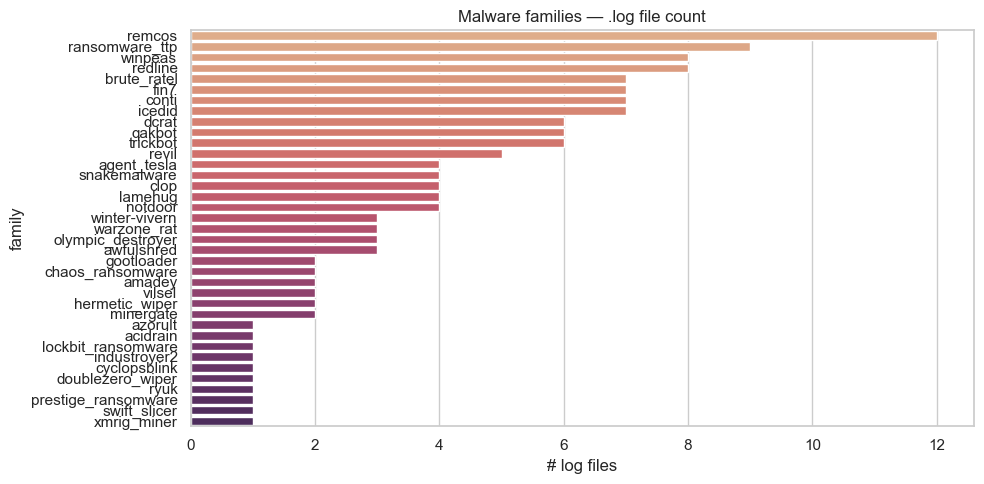

In [2]:
# --- Technique inventory ---
tech_root = Path(SPLUNK_TECHNIQUES)

technique_meta = {}  # tcode -> {scenarios, log_count, yml_techniques}
for tcode_dir in sorted(tech_root.iterdir()):
    if not tcode_dir.is_dir():
        continue
    tcode = tcode_dir.name
    scenarios, logs = [], []
    tcodes_from_yml = []
    for scenario in sorted(tcode_dir.iterdir()):
        if not scenario.is_dir():
            continue
        scenarios.append(scenario.name)
        logs.extend(list(scenario.glob('*.log')))
        for yml in scenario.glob('*.yml'):
            try:
                doc = yaml.safe_load(yml.read_text(encoding='utf-8'))
                if isinstance(doc, dict):
                    t = doc.get('mitre_technique', [])
                    tcodes_from_yml.extend(t if isinstance(t, list) else [t])
            except Exception:
                pass
    technique_meta[tcode] = {
        'scenarios': len(scenarios),
        'log_files': len(logs),
        'yml_tcodes': tcodes_from_yml,
    }

print(f'ATT&CK technique folders : {len(technique_meta)}')
print(f'Total scenario dirs      : {sum(v["scenarios"] for v in technique_meta.values())}')
print(f'Total .log files         : {sum(v["log_files"] for v in technique_meta.values())}')

# Malware inventory
mal_root = Path(SPLUNK_MALWARE_DIR)
malware_meta = {}
for family_dir in sorted(mal_root.iterdir()):
    if not family_dir.is_dir():
        continue
    variants = [d for d in family_dir.iterdir() if d.is_dir()]
    logs = list(family_dir.rglob('*.log'))
    malware_meta[family_dir.name] = {'variants': len(variants), 'log_files': len(logs)}

print(f'\nMalware families : {len(malware_meta)}')
print(f'Total variants   : {sum(v["variants"] for v in malware_meta.values())}')
print(f'Total .log files : {sum(v["log_files"] for v in malware_meta.values())}')

# Plot malware family sizes
mal_df = (pd.DataFrame.from_dict(malware_meta, orient='index')
            .sort_values('log_files', ascending=False)
            .reset_index().rename(columns={'index': 'family'}))
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=mal_df, x='log_files', y='family', ax=ax, palette='flare')
ax.set_title('Malware families — .log file count')
ax.set_xlabel('# log files')
plt.tight_layout()
plt.show()

## ATT&CK Tactic Distribution

With 293 technique folders, the Splunk corpus covers far more T-codes than the OTRF KB (256 entries). This cell maps each T-code to its tactic(s) via the KB and plots the distribution.

This is important for the pipeline because tactic coverage determines which **attack phases** the model can attribute. A corpus skewed toward a few tactics will produce a biased attribution model — the chart makes that bias visible before training.

T-codes in Splunk corpus : 293
KB coverage              : 245 / 293 (83.6%)


F:\GECAD\_cache\tmp\ipykernel_7972\416007770.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tac_df, x='count', y='tactic', ax=ax, palette='mako_r')


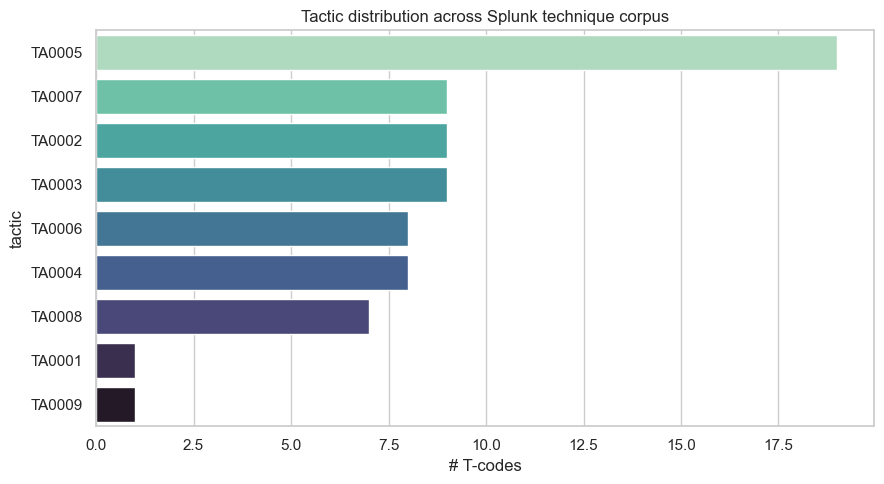

In [3]:
# --- Tactic distribution (via KB lookup) ---
kb = build_kb()
tid_to_tactics = {e.technique_id: e.tactic_ids for e in kb}

all_tcodes = list(technique_meta.keys())
tactic_counter = Counter(
    t for tc in all_tcodes
    for t in tid_to_tactics.get(tc, [])
    if t
)

tac_df = pd.DataFrame(tactic_counter.most_common(), columns=['tactic', 'count'])
kb_covered = sum(1 for tc in all_tcodes if tc in tid_to_tactics)

print(f'T-codes in Splunk corpus : {len(all_tcodes)}')
print(f'KB coverage              : {kb_covered} / {len(all_tcodes)} ({100*kb_covered/len(all_tcodes):.1f}%)')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=tac_df, x='count', y='tactic', ax=ax, palette='mako_r')
ax.set_title('Tactic distribution across Splunk technique corpus')
ax.set_xlabel('# T-codes')
plt.tight_layout()
plt.show()

## Full Event Load — Technique Corpus

Load all Sysmon events from the 293 ATT&CK technique folders. Each event arrives with:
- `attck_technique` — the T-code from the folder name (ground-truth label)
- `label = 1` — all events are confirmed malicious
- `dataset_source = "Splunk"`

The EventID distribution gives a first look at which Sysmon event types dominate across the technique corpus, which directly informs **feature importance** for the encoder and sequence models.

Events loaded    : 2,065,466
Label distribution: {1: 2065466}
Unique T-codes   : 177
Columns          : ['event_id', 'utc_time', 'process_guid', 'process_id', 'image', 'command_line', 'current_dir', 'user', 'integrity_level', 'parent_guid', 'parent_id', 'parent_image', 'parent_cmdline', 'image_loaded', 'signed', 'signature', 'sig_status', 'target_object', 'details', 'target_image', 'granted_access', 'call_trace', 'dest_ip', 'dest_port', 'dest_hostname', 'target_filename', 'event_type', 'pipe_name', 'query_name', 'query_results', 'rule_name', 'hashes', 'label', 'dataset_source', 'attck_technique']


F:\GECAD\_cache\tmp\ipykernel_7972\821000646.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eid_df, x='count', y='name', ax=ax, palette='Blues_r')


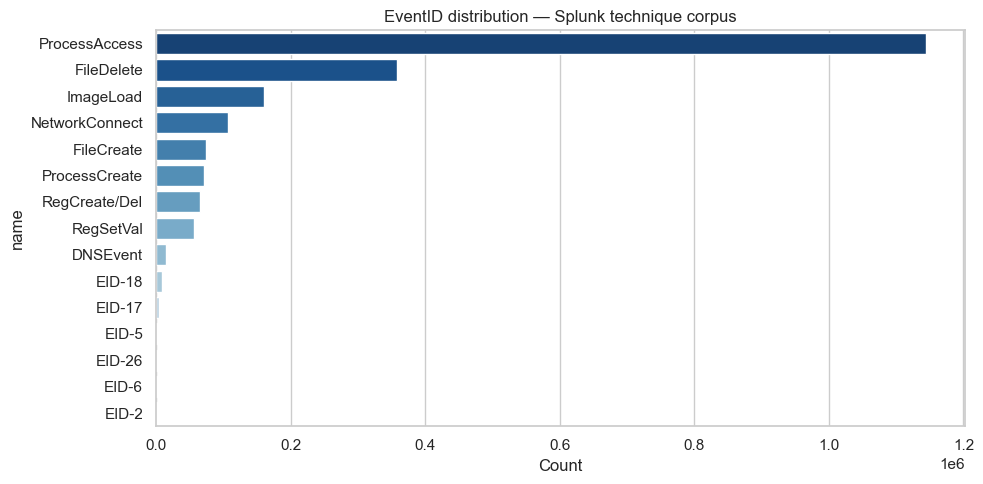

In [6]:
# --- Load all events (technique corpus) ---
from data.ingest.splunk import iter_techniques

chunks = []
tcode_event_counts = Counter()
eid_counts = Counter()
img_counts = Counter()

for chunk in iter_techniques():
    chunks.append(chunk)
    tcode_event_counts.update(chunk['attck_technique'].tolist())
    eid_counts.update(chunk['event_id'].dropna().astype(int).tolist())
    basenames = (
        chunk['image'].dropna()
        .str.split('\\').str[-1]
        .str.lower()
        .replace('', pd.NA)
        .dropna()
    )
    img_counts.update(basenames.tolist())

if chunks:
    df = pd.concat(chunks, ignore_index=True)
    print(f'Events loaded    : {len(df):,}')
    print(f'Label distribution: {df["label"].value_counts().to_dict()}')
    print(f'Unique T-codes   : {df["attck_technique"].nunique()}')
    print(f'Columns          : {list(df.columns)}')
else:
    print('No events loaded — check Splunk log paths.')
    df = pd.DataFrame()

# EventID distribution
if eid_counts:
    eid_df = pd.DataFrame(eid_counts.most_common(15), columns=['event_id', 'count'])
    eid_df['name'] = eid_df['event_id'].map(lambda x: EID_MAP.get(x, f'EID-{x}'))
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=eid_df, x='count', y='name', ax=ax, palette='Blues_r')
    ax.set_title('EventID distribution — Splunk technique corpus')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

## Process Image Distribution

Shows the top 20 process executables by frequency across all technique scenarios. The distribution is entirely data-driven — no predetermined list of "suspicious" binaries is used. Whatever the corpus surfaces as high-frequency is what the model should learn from, not a blacklist imposed before training.

F:\GECAD\_cache\tmp\ipykernel_7972\1614704700.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=img_df, x='count', y='image', ax=ax, palette='rocket_r')


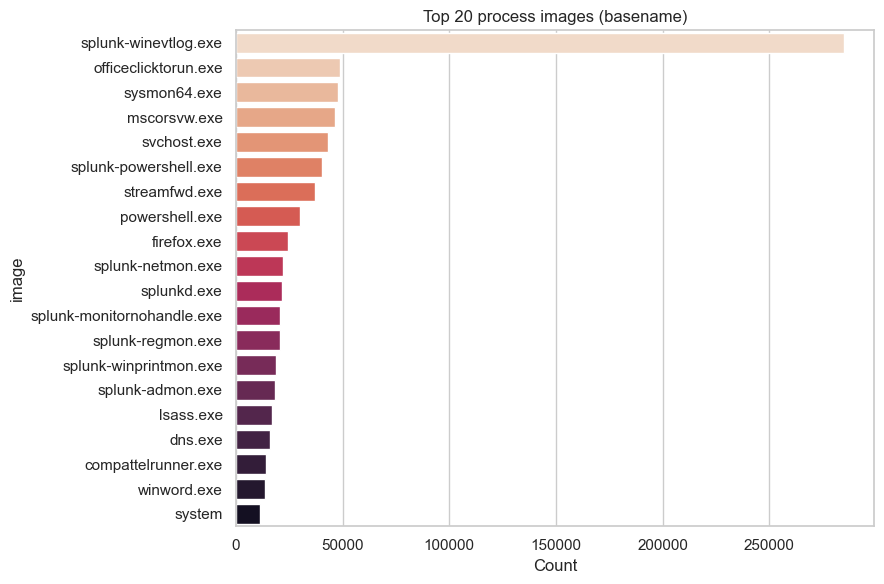

In [7]:
# --- Top process images ---
if not df.empty:
    img_df = pd.DataFrame(img_counts.most_common(20), columns=['image', 'count'])
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=img_df, x='count', y='image', ax=ax, palette='rocket_r')
    ax.set_title('Top 20 process images (basename)')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

## Network Activity — EventIDs 3 & 22

Splunk attack scenarios cover a wider range of techniques than APT29, so the network profile here reflects a **broader threat landscape** rather than a single campaign:

- **EventID 22 (DNSEvent)** — technique-specific DNS queries; C2 frameworks, reconnaissance (T1016, T1018), and data staging all generate distinct DNS patterns.
- **EventID 3 (NetworkConnect)** — destination IPs and ports across all 293 techniques. Lateral movement techniques (T1021.x) will dominate with SMB (445), WMI (135), WinRM (5985), and RDP (3389) ports.

Comparing this network profile against the APT29 network profile from notebook 03 shows how campaign-level network behaviour differs from technique-level isolation.

DNS events  (EID 22): 14,258
Net events  (EID 3) : 106,393


F:\GECAD\_cache\tmp\ipykernel_7972\2970330804.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_q, x='count', y='query_name', ax=axes[0], palette='Blues_r')
F:\GECAD\_cache\tmp\ipykernel_7972\2970330804.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_ip, x='count', y='dest_ip', ax=axes[1], palette='Oranges_r')
F:\GECAD\_cache\tmp\ipykernel_7972\2970330804.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_port, x='count', y='dest_port', ax=axes[2], palette='Greens_r')


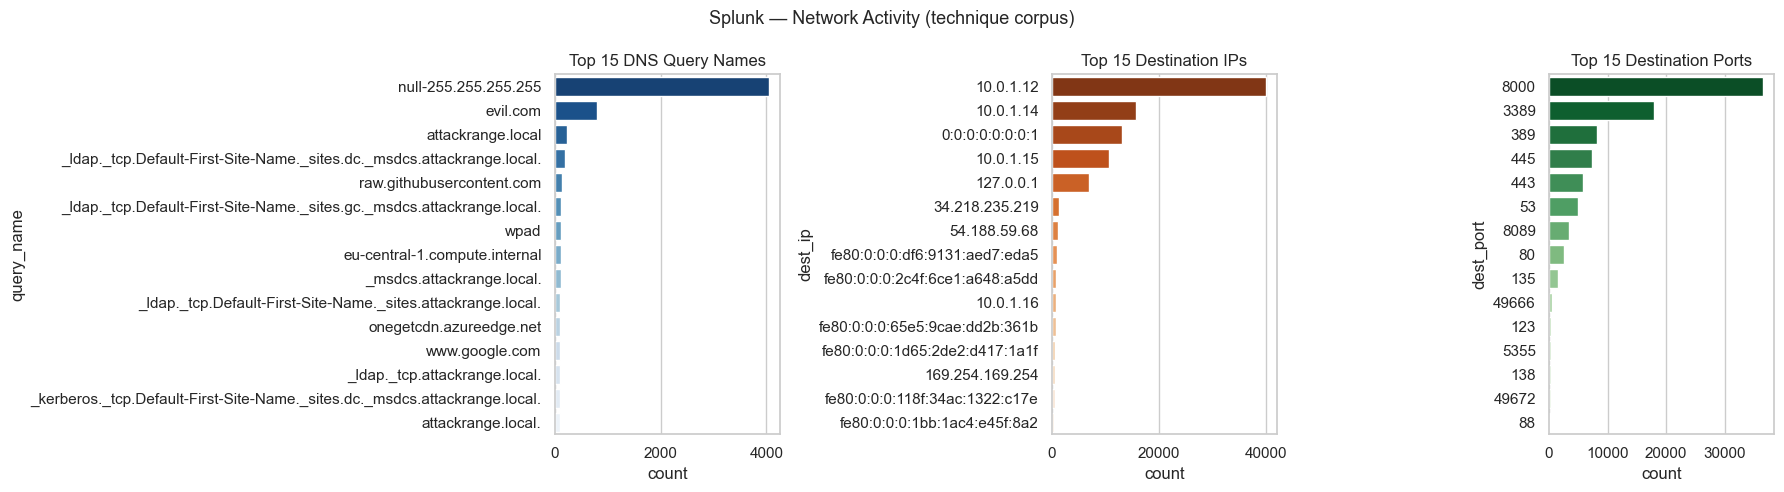

In [8]:
# --- Network analysis (EventIDs 3, 22) ---
if not df.empty:
    df_dns  = df[df['event_id'] == 22].copy()
    df_net3 = df[df['event_id'] == 3].copy()

    print(f'DNS events  (EID 22): {len(df_dns):,}')
    print(f'Net events  (EID 3) : {len(df_net3):,}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    if not df_dns.empty:
        top_q = (df_dns['query_name'].replace('', pd.NA).dropna()
                 .value_counts().head(15).reset_index())
        top_q.columns = ['query_name', 'count']
        sns.barplot(data=top_q, x='count', y='query_name', ax=axes[0], palette='Blues_r')
        axes[0].set_title('Top 15 DNS Query Names')
    else:
        axes[0].text(0.5, 0.5, 'No DNS events', ha='center', va='center')
        axes[0].set_title('DNS Query Names')

    if not df_net3.empty:
        top_ip = df_net3['dest_ip'].value_counts().head(15).reset_index()
        top_ip.columns = ['dest_ip', 'count']
        sns.barplot(data=top_ip, x='count', y='dest_ip', ax=axes[1], palette='Oranges_r')
        axes[1].set_title('Top 15 Destination IPs')

        top_port = (pd.to_numeric(df_net3['dest_port'], errors='coerce')
                    .dropna().astype(int).value_counts().head(15).reset_index())
        top_port.columns = ['dest_port', 'count']
        top_port['dest_port'] = top_port['dest_port'].astype(str)
        sns.barplot(data=top_port, x='count', y='dest_port', ax=axes[2], palette='Greens_r')
        axes[2].set_title('Top 15 Destination Ports')
    else:
        axes[1].text(0.5, 0.5, 'No network events', ha='center', va='center')
        axes[2].text(0.5, 0.5, 'No network events', ha='center', va='center')

    plt.suptitle('Splunk — Network Activity (technique corpus)', fontsize=13)
    plt.tight_layout()
    plt.show()

## Technique Coverage vs OTRF Knowledge Base

Cross-reference the 293 Splunk T-codes against the OTRF ATT&CK KB (256 entries) to understand overlap and unique coverage:

- **Both** — techniques present in both Splunk and the OTRF KB; these T-codes will have the richest multi-source evidence for the model.
- **Splunk only** — techniques Splunk adds beyond the KB; expands tactic/technique diversity.
- **KB only** — OTRF KB entries not yet covered by Splunk scenarios; highlights potential gaps in the training corpus.

This overlap analysis drives the dataset mixing strategy: techniques covered by both sources can be used for cross-dataset validation, while Splunk-only techniques are pure additions to training coverage.

T-codes only in Splunk       : 48
T-codes only in KB (OTRF)    : 11
T-codes in both              : 245


F:\GECAD\_cache\tmp\ipykernel_7972\653741303.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=venn, x='count', y='set', ax=ax, palette='Set2')


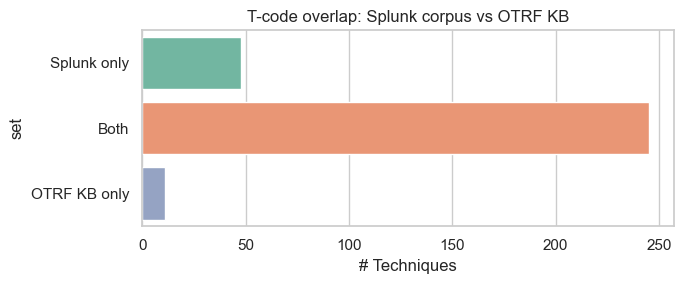


T-codes in Splunk but NOT in KB (first 20):
['T1027.006', 'T1027.011', 'T1027.013', 'T1035.009', 'T1036.002', 'T1036.005', 'T1036.009', 'T1040', 'T1041', 'T1053', 'T1059.002', 'T1070.003', 'T1072', 'T1095', 'T1102', 'T1102.002', 'T1113', 'T1129', 'T1133', 'T1134']


In [9]:
# --- Technique coverage vs OTRF KB ---
splunk_tids = set(technique_meta.keys())
kb_tids     = set(tid_to_tactics.keys())

only_splunk = splunk_tids - kb_tids
only_kb     = kb_tids - splunk_tids
both        = splunk_tids & kb_tids

print(f'T-codes only in Splunk       : {len(only_splunk)}')
print(f'T-codes only in KB (OTRF)    : {len(only_kb)}')
print(f'T-codes in both              : {len(both)}')

# Venn-style bar
venn = pd.DataFrame([
    {'set': 'Splunk only',   'count': len(only_splunk)},
    {'set': 'Both',          'count': len(both)},
    {'set': 'OTRF KB only',  'count': len(only_kb)},
])
fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(data=venn, x='count', y='set', ax=ax, palette='Set2')
ax.set_title('T-code overlap: Splunk corpus vs OTRF KB')
ax.set_xlabel('# Techniques')
plt.tight_layout()
plt.show()

if only_splunk:
    print(f'\nT-codes in Splunk but NOT in KB (first 20):')
    print(sorted(only_splunk)[:20])

## Per-Technique Event Volume Heatmap

Event volume varies orders of magnitude across techniques — some T-codes have thousands of events, others only a handful. This chart shows the top 40 techniques by event count, grouped and coloured by tactic.

**Why this matters for training:**
- Heavily skewed event counts introduce class imbalance at the technique level; the model may over-specialise on high-volume techniques.
- The tactic colouring reveals whether the imbalance is tactic-wide (e.g., all execution techniques are sparse) or technique-specific.
- Low-volume techniques (< 100 events) are candidates for over-sampling or exclusion from per-technique evaluation metrics.

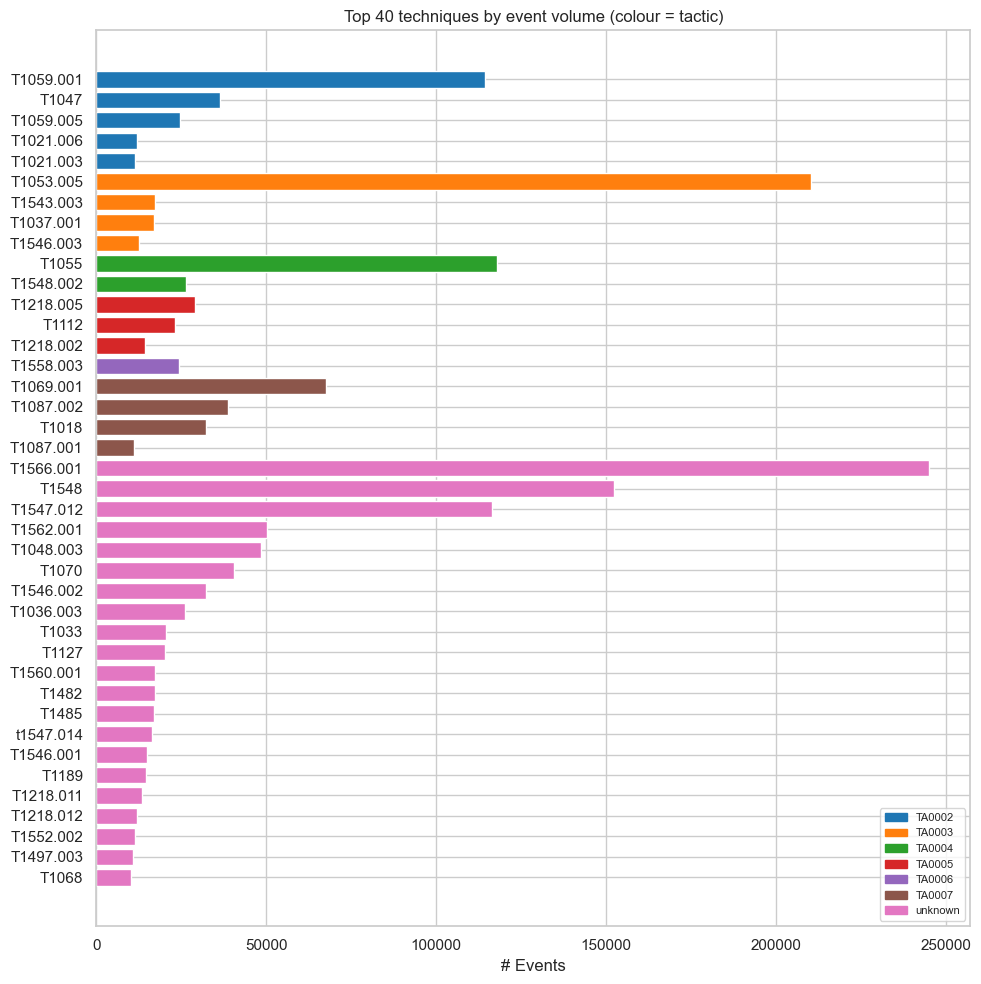

: 

In [ ]:
# --- Per-technique event volume heatmap ---
if tcode_event_counts:
    top_tcodes = pd.DataFrame(
        tcode_event_counts.most_common(40), columns=['technique', 'events']
    )
    top_tcodes['tactic'] = top_tcodes['technique'].map(
        lambda t: (tid_to_tactics.get(t, ['unknown']) or ['unknown'])[0]
    )
    top_tcodes = top_tcodes.sort_values(['tactic', 'events'], ascending=[True, False])

    fig, ax = plt.subplots(figsize=(10, 10))
    colors = sns.color_palette('tab10', n_colors=top_tcodes['tactic'].nunique())
    tactic_color = {t: c for t, c in zip(top_tcodes['tactic'].unique(), colors)}
    bar_colors = top_tcodes['tactic'].map(tactic_color)

    ax.barh(top_tcodes['technique'], top_tcodes['events'], color=bar_colors.tolist())
    ax.set_title('Top 40 techniques by event volume (colour = tactic)')
    ax.set_xlabel('# Events')
    ax.invert_yaxis()

    from matplotlib.patches import Patch
    legend = [Patch(color=c, label=t) for t, c in tactic_color.items()]
    ax.legend(handles=legend, loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('tcode_event_counts is empty — run the event loading cell first.')